- 각 변수는 어떤 값을 갖는가 ?
- 각 품종의 데이터 수는 동일한가 ?
- 꽃잎과 꽃받침의 크기는 어떻게 분포하는가 ?
- 이상치로 보이는 관측값은 존재하는가 ?
- 꽃잎 길이와 너비는 서로 어떠한 관계를 갖는가 ?
- 품종에 따라 측정값의 분포가 다른가 ?
- 여러 수치형 변수 중 어떤 변수들이 강한 관계를 갖는가 ?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.datasets import load_iris

In [2]:
sns.set_theme(
    context='talk',
    style='darkgrid',
)

In [3]:
iris = load_iris(as_frame=True)

df=iris.frame.copy()

In [4]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
df.columns # sepal length 공백 갖는 것보단 _넣어주는 게 좋다

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='str')

In [6]:
df = df.rename(
    columns={
        'sepal length (cm)' : 'sepal_length',
        'sepal width (cm)' : 'sepal_width',
        'petal length (cm)' : 'petal_length',
        'petal width (cm)' : 'petal_width',
    }
)

df.head()

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
# 각각의 target이 어떤 데이터를 갖고있는지 확인 , target : 0번부터 시작>index
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [8]:
# target 데이터를 범주형 데이터로 변환하는 게 유리

target_map=dict(enumerate(iris.target_names))  #enumerate(순서값을 가지고 순서값을 index에서 따옴)
# 형태로 바꿔주고 dict(딕셔너리)로 덮어씌운다 , 키값으로 순서 가지니까 0번에 세토사 이런식으로 넣어준다

df['species']=df['target'].map(target_map)
df= df.drop(columns='target') #target 컬럼이 없어진다. drop하면 반환된다,재할당 꼭해줘야 ('df='넣어주기)


In [9]:
# 데이터 전 처리 했으니까 shape 봐야지

df.shape

(150, 5)

In [10]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [11]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='str')

In [12]:
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

In [13]:
# 수치형 변수만 고를 수 있게
numeric_columns = df.select_dtypes(include='number').columns.to_list()

print(type(numeric_columns))
print(numeric_columns)

<class 'list'>
['sepal_length', 'sepal_width', 'petal_length', 'petal_width']


In [14]:
categorical_columns = df.select_dtypes(exclude='number').columns.to_list()

print(type(categorical_columns))
print(categorical_columns)

<class 'list'>
['species']


In [15]:
df.isna().sum() # 결측치 유무 확인 , 데이터 시각화 시 결측지 많거나 듬성하면 갑자기 없어지거나 확올라가거나 할 수 잇음
# 결측치를 빼는 게 나을지 판단해야

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [16]:
df.describe().round(2)  #round =반올림

,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


## 꽃잎 길이는 어떤 분포를 갖고 있는가 ?
- 사용할 변수: petal_length

## 품종마다 꽃잎 길이가 다른가 ?
- 사용할 변수: species , petal_length

## 꽃잎 길이와 꽃잎 너비 사이에 관계가 있는가?
- 사용할 변수: petal_length , petal_width

## 꽃잎 길이와 너비의 관계가 품종에 따라 다르게 나타나는가?
- 사용할 변수 : petal_length, petal_width, species

## 네 가지 수치형 변수 전체에서는 어떤 관계가 나타나는가?
- 사용할 변수 : 모든 수치형 변수

## 단변량 변수

수치형 변수
- 중심의 위치
- 전체 범위
- 분포의 모양
- 값이 집중된 영역
- 극단적으로 떨어진 관측값

In [17]:
df['petal_length'].describe().round(2)

count    150.00
mean       3.76
std        1.77
min        1.00
25%        1.60
50%        4.35
75%        5.10
max        6.90
Name: petal_length, dtype: float64

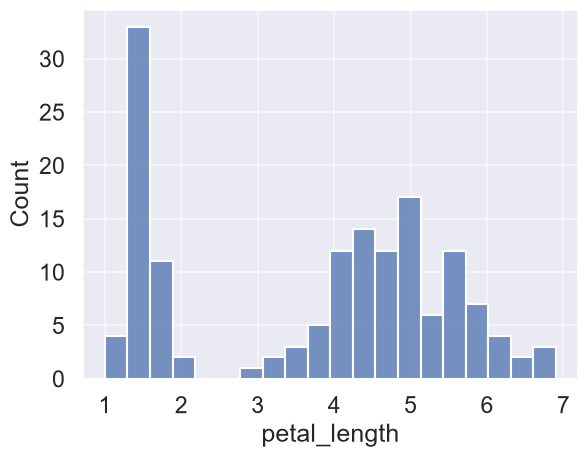

In [19]:
sns.histplot(
    data=df,
    x='petal_length',
    bins=20    #분포를 넓게 보여줌 bin=구간 , 구간을 20개로 늘린 것
)

plt.show()    #특정 구간에 몰려있는 것들도 있고 중간값은 거의 없다

## KDE(Kernel Density Estimation)

KDE(커널 밀도 추정)는 수집한 데이터의 분포를 매끄러운 곡선 형태로 추정하여 나타내는 통계학적 방법,
히스토그램의 단점을 보완한 매끄러운 확률 밀도 그래프

히스토그램 구간의 경계 위치나 너비를 어떻게 설정하느냐에 따라서 그래프의 모양이 달라진다. ( 많아지면 완만해보이고 적으면 급격해보인다) 연속적인 데이터의 흐름을 반영하기가 어렵다.

### 커널(Kernel)
하나의 데이터 포인트를 대표하는 원형 형태의 작은 함수(곡선)을 의미한다.

데이터 포인트 하나가 관측되었을 때, 이 값 근처에도 유사한 값이 존재할 확률이 높다라는 것을 나타내기 위한 확률 분포 곡선

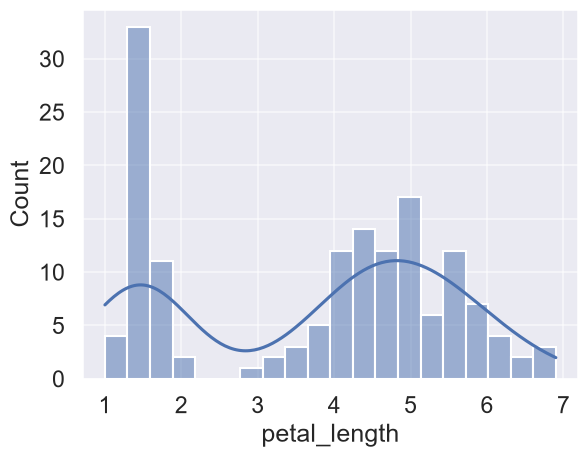

In [21]:
sns.histplot(
    data=df,
    x='petal_length',
    bins=20,
    kde=True
)

plt.show()   # 품종은 고려하지 않은 시각화 데이터, 단변량 그래프 ( petal_length가 갖는 갯수만 나온거 )

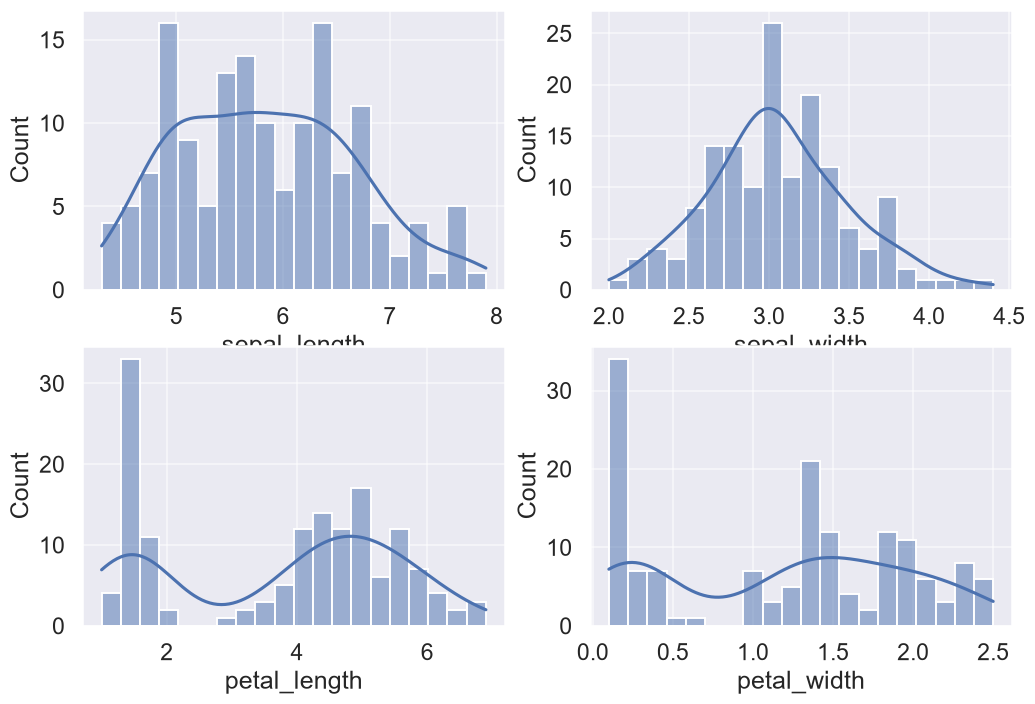

In [23]:
fig,axes = plt.subplots(nrows=2,ncols=2,figsize=(12,8))

#반복문 쓸 수 있다. zip 함수 : 배열과 배열을 묶어줌 , 차원이 다른건 묶어줄 수 없다
for ax,column_name in zip(axes.flat,numeric_columns):
    sns.histplot(
        data=df,
        x=column_name,
        bins=20,
        kde=True,
        ax=ax
    )

plt.show()
# [0,1,2,3]['a','b','c','d'] zip은 0-a 1-b,2-c,3-d를 묶어줌 , 불러올때 묶은 애들 다같이 불러올수있음
# axes.flat > 2차원 배열을 1차원 배열로 눌러준다

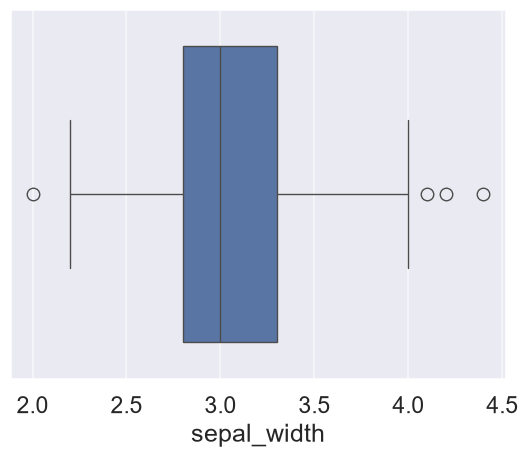

In [36]:
# 수치형 변수에 극단적인 값,이상치가 있는지 봐야한다. boxplot을 그리면 된다.

sns.boxplot(data=df,x='sepal_width')   #동그라미=이상치

plt.show()  # 파란칸 해당=중앙값 파란칸 왼쪽 =q1, 오른쪽=q3  왼쪽

In [29]:
q1=df['sepal_width'].quantile(0.25)
q3=df['sepal_width'].quantile(0.75)

iqr=q3-q1

# 데이터를 작은 값부터 정렬했을 때 아래에서 25% 지점의 값을 구합니다. 이것을 **Q1(제1사분위수)**이라고 합니다.
# 75% 지점의 값을 구합니다. 이것을 **Q3(제3사분위수)**라고 합니다.
# **IQR(Interquartile Range)**은 Q1과 Q3 사이의 거리 , 데이터의 가운데 50%가 얼마나 넓게 퍼져 있는지

lower_bound = q1-1.5*iqr
upper_bound = q3+1.5*iqr

# 일반적으로 IQR 방식에서는 다음 범위를 벗어나면 이상치 후보로 판단합니다.

#하한 = Q1 - 1.5 × IQR
#상한 = Q3 + 1.5 × IQR

# sepal_width < lower_bound 이면 너무 작은 값으로 보고,
# sepal_width > upper_bound 이면 너무 큰 값으로 보고 확인이 필요한 이상치 후보로 판단 ( 무조건 잘못된거 x )

print(f'q1={q1}')
print(f'q3={q3}')
print(f'iqr={iqr}')
print(f'lower_bound={lower_bound}')
print(f'upper_bound={upper_bound}')

# 판단 기준은 2.05 ~ 4.05 범위를 벗어난 sepal_width 값은 이상치 후보라는 뜻

# 핵심 공식 3개
# IQR = Q3 - Q1
#하한 = Q1 - 1.5 × IQR
#상한 = Q3 + 1.5 × IQR

q1=2.8
q3=3.3
iqr=0.5
lower_bound=2.05
upper_bound=4.05


In [30]:
outlier = df[  #outlier 이상치
    (df['sepal_width']<lower_bound)
    |
    (df['sepal_width']>upper_bound)
]

outlier

,sepal_length,sepal_width,petal_length,petal_width,species
15,5.7,4.4,1.5,0.4,setosa
32,5.2,4.1,1.5,0.1,setosa
33,5.5,4.2,1.4,0.2,setosa
60,5.0,2.0,3.5,1.0,versicolor


In [31]:
len(outlier)  #4개 정도의 데이터가 이상치 후보에 들어간다

4

In [35]:
for column_name in numeric_columns:
    q1=df[column_name].quantile(0.25)
    q3=df[column_name].quantile(0.75)

    iqr=q3-q1

    lower_bound = q1-1.5*iqr   #하한선
    upper_bound = q3+1.5*iqr    #상한선

 # outlier = df[
  #  (df[column_name]<lower_bound)
   # |
   # (df[column_name]>upper_bound)   # 데이터 프레임은 조건을 걸면 boolyn 타입의 마스크가 된다 /
      # 파이썬에서 불린 타입을 합산하면 이상치만 나오는거,,
 # ]
outlier_count = ((df[column_name]<lower_bound)|(df[column_name]>upper_bound)).sum()

print(column_name,outlier_count)

petal_width 0


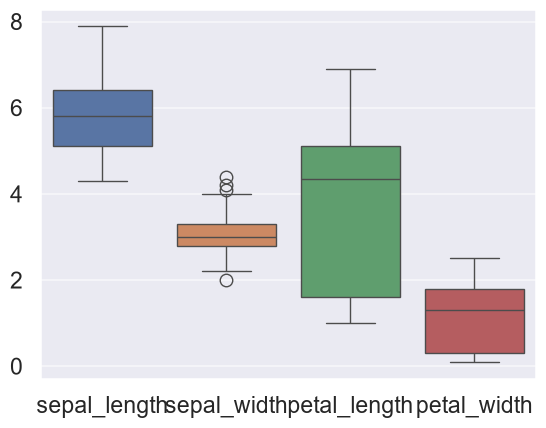

In [37]:
sns.boxplot(
    data=df[numeric_columns]
)

plt.show()

## 다변량 분석

- 수치형+수치형
- 범주형+수치형

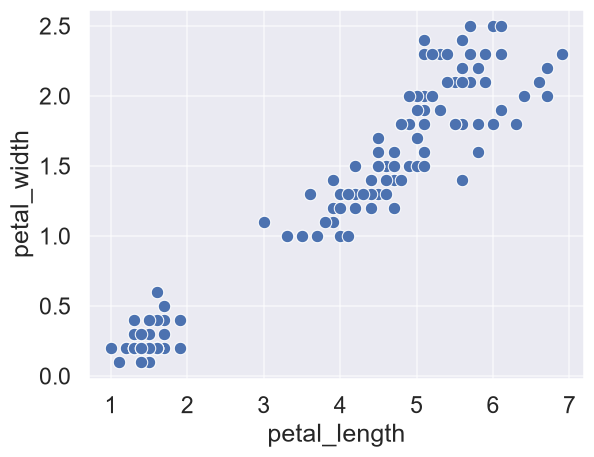

In [38]:
sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
)

plt.show()   # 꽃잎 길이가 크면 너비도 커지는 경향이 있네, 오른쪽 위에 분포 많이 하고있군

In [44]:
# 얼마만큼 상관 있는지 상관계수를 보고싶다
#df[numeric_columns].corr()

#꽃잎의 길이와 꽃잎의 너비에 대한 상관계수를 알고싶다.
correlation = df['petal_length'].corr(df['petal_width'])

print(correlation.round(2)) # 0.96=강한 양의 상관관계 갖는구나

0.96


# 회귀(Regression)

회귀는 하나 이상 변수의 변화(독립변수 X)가 다른 변수(종속변수,Y)에 미치는 영향을 수식으로 모델링하여 추정하는 기법

$Y = WX + b$     # W>가중치
> 회귀 : 부모와 자녀의 키관계를 연구, 부모의 키가 아주 크거나 작아도 자녀의 키는 전체 인구의 평균 크기로 돌아가려는 경향이 있다.에서 유래가 있음

## 회귀선(Regression Line)

산점도 상에서 흩어져 있는 데이터 포인트(점)들의 전체적인 추세나 경향을 가장 잘 대표하도록 그린
'최적의 선'을 의미

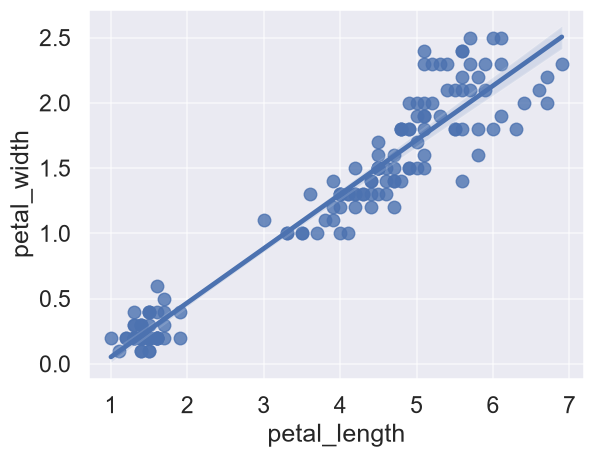

In [45]:
sns.regplot(   #regplot=회귀선 산점도
    data=df,
    x='petal_length',
    y='petal_width',
)

plt.show()

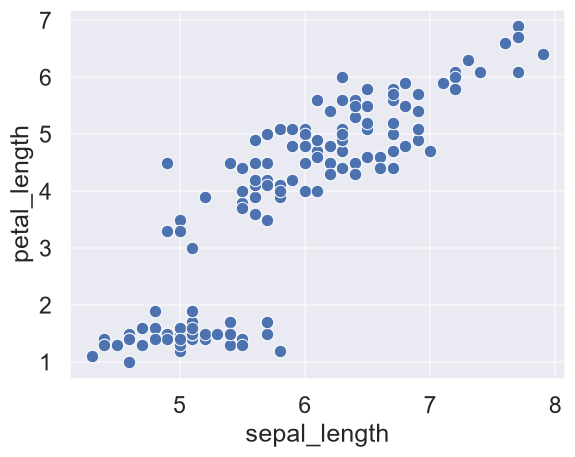

In [46]:
sns.scatterplot(
    data=df,
    x='sepal_length',
    y='petal_length'
)

plt.show()

In [48]:
round(df['sepal_length'].corr(df['petal_length']),2) #상관관계를 본다

np.float64(0.87)

In [50]:
# 품종별 평균 보고 어디에 모여있는지 본다
df.groupby('species')  # 그룹핑해서 데이터가 모인 상태임

In [53]:
species_mean = df.groupby('species')[numeric_columns].mean().round(2)

species_mean


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


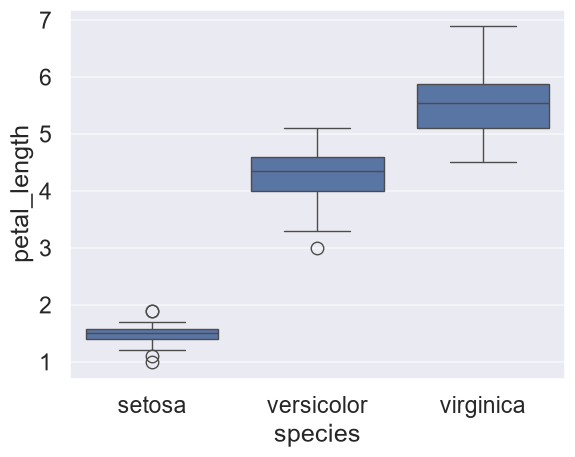

In [54]:
sns.boxplot(
    data=df,
    x='species',
    y='petal_length'
)

plt.show()   #독립변수만 놓고 볼 땐 몰랐는데 품종별로 나눠서 보니까 setosa에서 이상치가 많네,얘가 영향을 끼쳤네

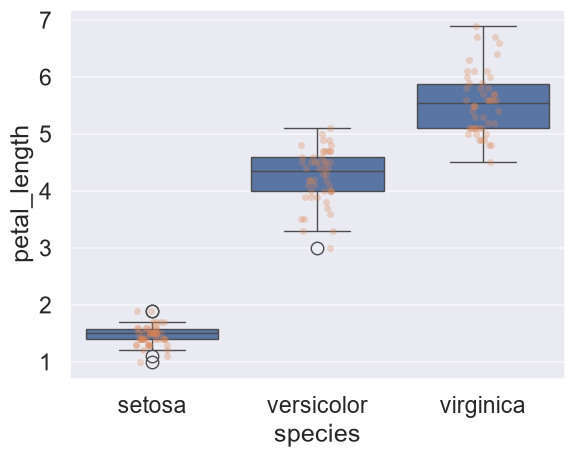

In [55]:
ax=sns.boxplot(
    data=df,
    x='species',
    y='petal_length'
)

sns.stripplot(
    data=df,
    x='species',
    y='petal_length',
    alpha=0.3,
    ax=ax,
)

plt.show()   #이상치도 실제로 보니까 넣어도 되는 값이네 판단 가능

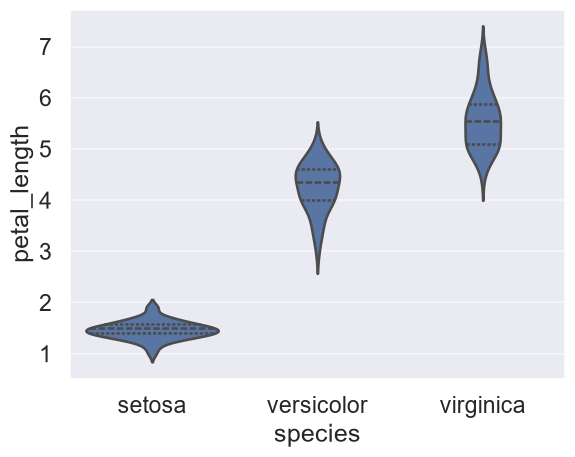

In [56]:
sns.violinplot(
    data=df,
    x='species',
    y='petal_length',
    inner='quart'
)

plt.show()  #종마다 다른 분포를 띌 수 있구나

<Axes: xlabel='petal_length', ylabel='Count'>

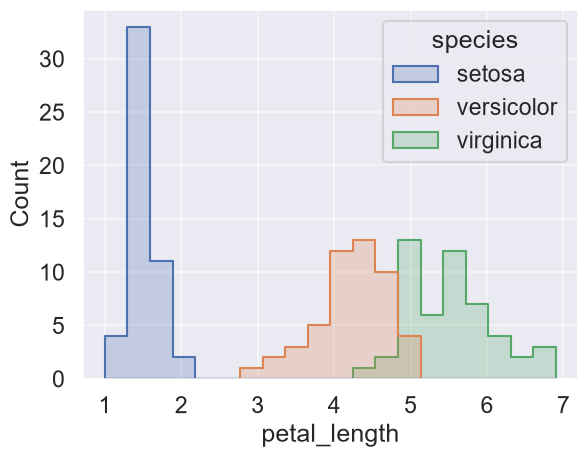

In [61]:
sns.histplot(
    data=df,
    x='petal_length',
    hue='species',
    bins=20,
    element='step'  #막대가 아닌 이어져있는 그래프로 분포 보고싶을 때
)


In [ ]:
품종별 꽃잎의 너비와 길이의 상관관계(다변량분석)

<Axes: xlabel='petal_length', ylabel='petal_width'>

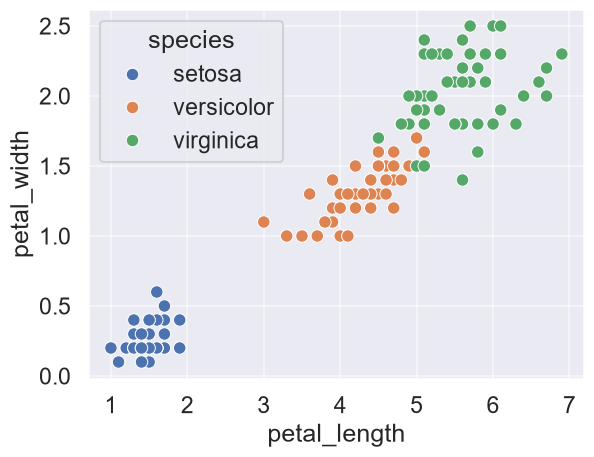

In [63]:
sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species'
)

전체적으로 꽃잎 길이가 너비와 함께 증가하지만, 종을 포함하여 확인하니 세 품종이 서로 다른 영역에 위치하고 있는 것을 확인했다.

<Axes: xlabel='sepal_length', ylabel='sepal_width'>

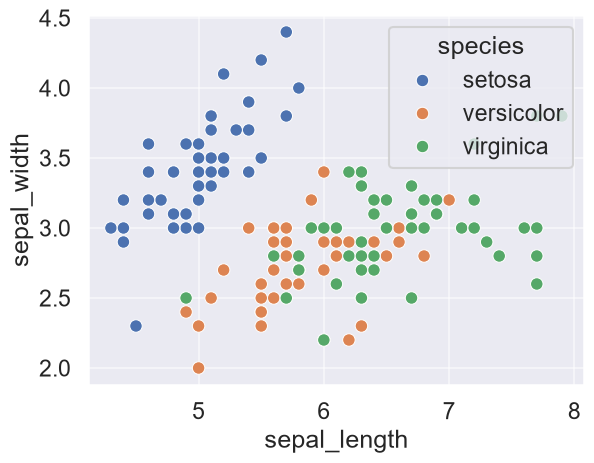

In [64]:
sns.scatterplot(
    data=df,
    x='sepal_length',
    y='sepal_width',
    hue='species'
)   #관계를 어떻게 갖는지 잘 모르겠음, 아래 그래프는

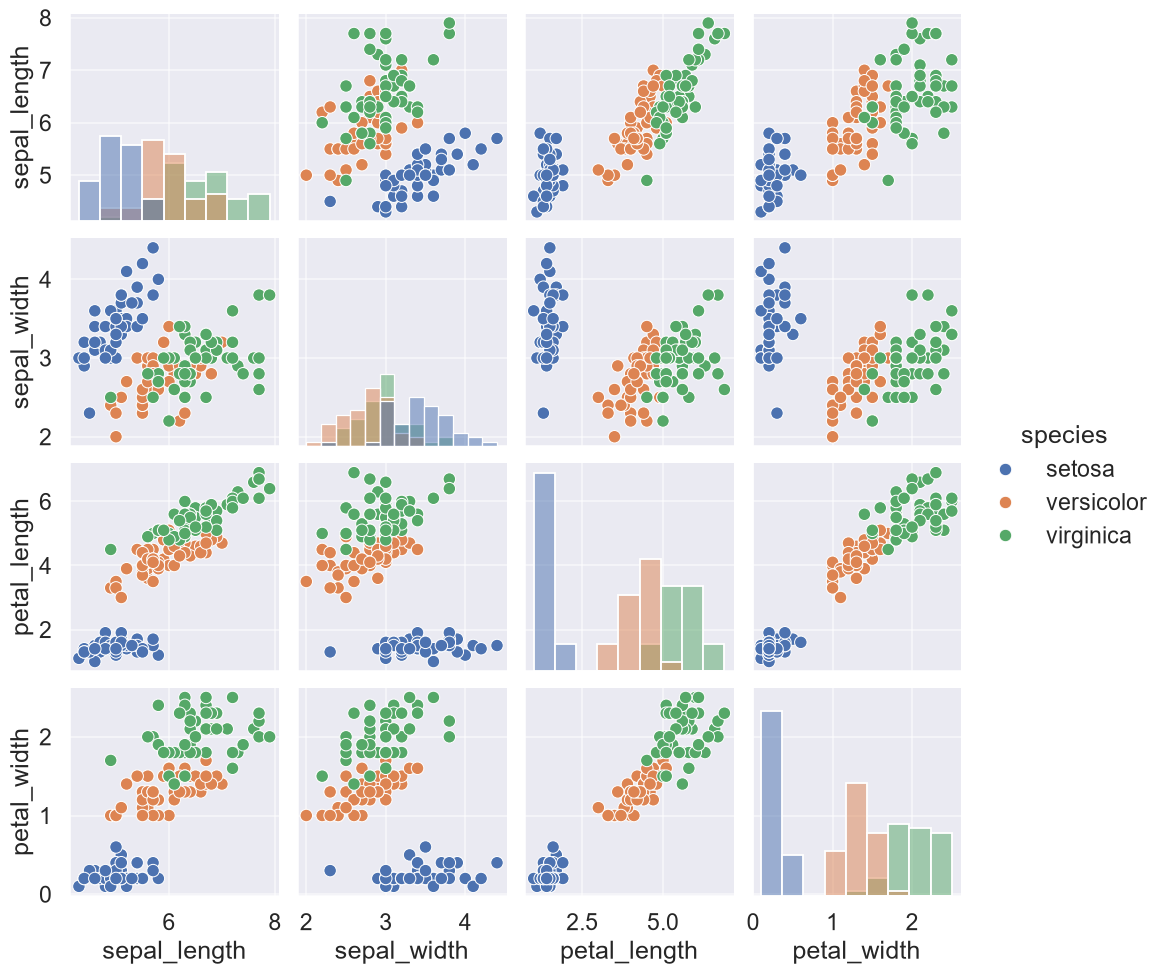

In [67]:
sns.pairplot( #상관관계를 그래프로 만듦
    data=df,
    vars=numeric_columns,
    hue='species',
    diag_kind='hist'  #대각선의 종류=히스토그램
)

plt.show()

- 각 변수의 분포
-

In [ ]:
sns.pairplot
    data=df,
    vars=numeric_columns,
    hue='species',
    diag_kind='hist'
)

1. 대각선 : 품종별 변수 분포를 확인할때 사용
2. 비대각선 : 수치형 변수 사이의 관계를 확인
3. 색상그룹 : 품종이 서로 분리되는 영역이 어디인지 확인
4. 겹치는 영역 : 품종 구분이 어려운 변수 조합이 무엇인지를 확인

In [68]:
#fig =그림을 반환 ax=개별 그래프 내용을 반환 / subplot은 tuple((,))을 반환,튜플(())안에 든게 첫번째 변수(fig),두번째 변수ax에 들어감
def test_1():
    return(1,'2')

a,b = test_1()

print(a)
print(b)


1
2


In [75]:
corr_matrix = df[numeric_columns].corr().round(2)

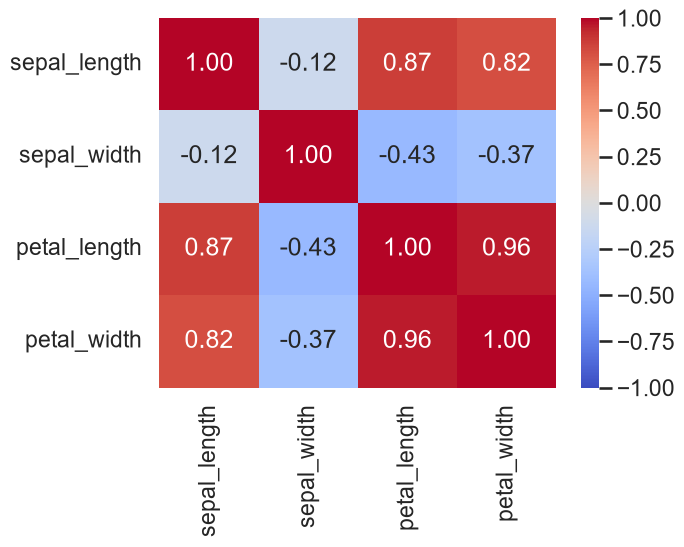

In [77]:
sns.heatmap(
    data=corr_matrix,
    annot=True,
    fmt='.2f',
    vmax=1,
    vmin=-1,
    center=0, #중앙값
    cmap='coolwarm',
)

plt.show()  #꽃잎의 길이와 너비가 상관관계가 젤높다

- 세 품종은 꽃잎 길이에서 뚜렷한 차이를 보인다.
- 꽃잎 길이와 꽃잎 너비는 강한 양의 관계를 갖는다.
- 꽃잎 관련 변수는 꽃밭침 관련 변수보다 품종별 구분이 명확하다.

### 세 품종은 꽃잎 길이에서 뚜렷한 차이를 보인다.

In [78]:
# 품종별 평균 구하기
petal_mean = df.groupby('species')['petal_length'].mean()

petal_mean.round(2)

species
setosa        1.46
versicolor    4.26
virginica     5.55
Name: petal_length, dtype: float64

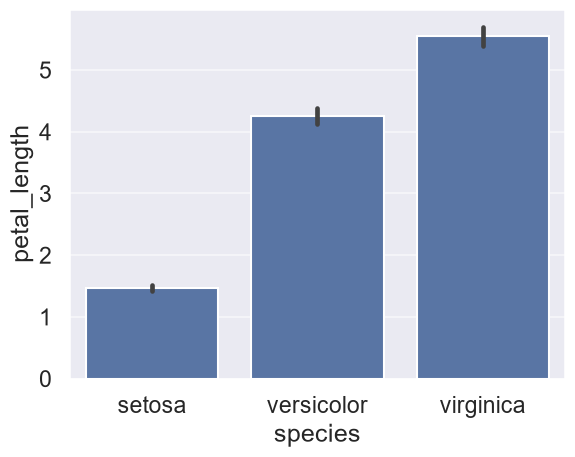

In [79]:
order=petal_mean.index

sns.barplot(
    data=df,
    x='species',
    y='petal_length',
    order=order,
    estimator='mean',
)
plt.show()  # 세 품종이 길이에서 차이가 있다를 잘 보여줄 수 있음

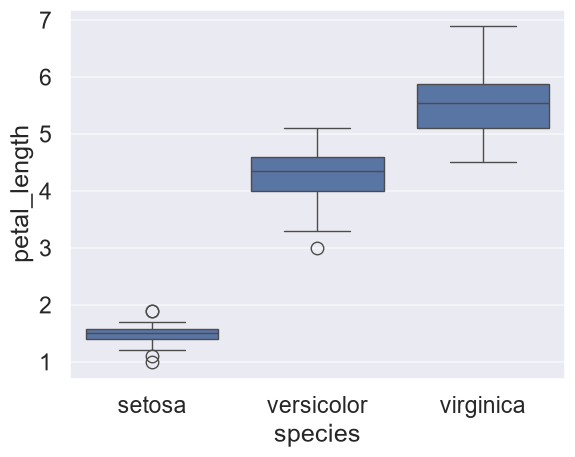

In [80]:
sns.boxplot(
    data=df,
    x='species',
    y='petal_length',
)

plt.show()

1. 평균의 차이를 강조 : 막대그래프
2. 분포의 차이를 강조 : 상자수염그래프 혹은 바이올린 그래프
3. 두 변수 간 관계를 강조 : 산점도
4. 선형관계를 강조 : 회귀선 (산점도)

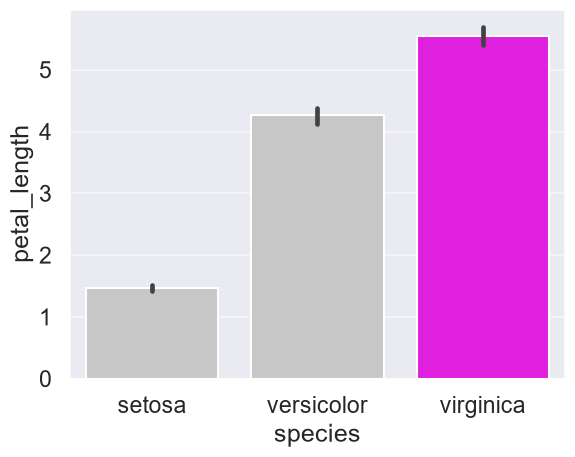

In [85]:
highlight_palette={
    'setosa':'#C7C7C7',    # ~색상 헥스값 검색 후 복사해서 쓰면된다.
    'versicolor':'#C7C7C7',
    'virginica':'#FF00FF'
}

sns.barplot(
    data=df,
    x='species',
    y='petal_length',
    palette=highlight_palette,
    hue='species',
    estimator='mean',
    legend=False #범례는 안넣음
)
plt.show()